In [ ]:
!pip install datasets transformers scikit-learn pandas langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.6 MB/s eta 0:00:00


In [ ]:
# Load HuggingFace Dataset
from datasets import load_dataset
import pandas as pd

# Fetch Bitext Dataset
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")

# Convert To Pandas
df = dataset.to_pandas()

# Format Needed Columns
df = df[['instruction', 'intent']]
df = df.rename(columns={'instruction': 'ticket', 'intent': 'true_label'})

# Show DataFrame Head
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

,ticket,true_label
0,question about cancelling order {{Order Number}},cancel_order
1,i have a question about cancelling oorder {{Or...,cancel_order
2,i need help cancelling puchase {{Order Number}},cancel_order
3,I need to cancel purchase {{Order Number}},cancel_order
4,"I cannot afford this order, cancel purchase {{...",cancel_order


true_label
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
set_up_shipping_address      997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64


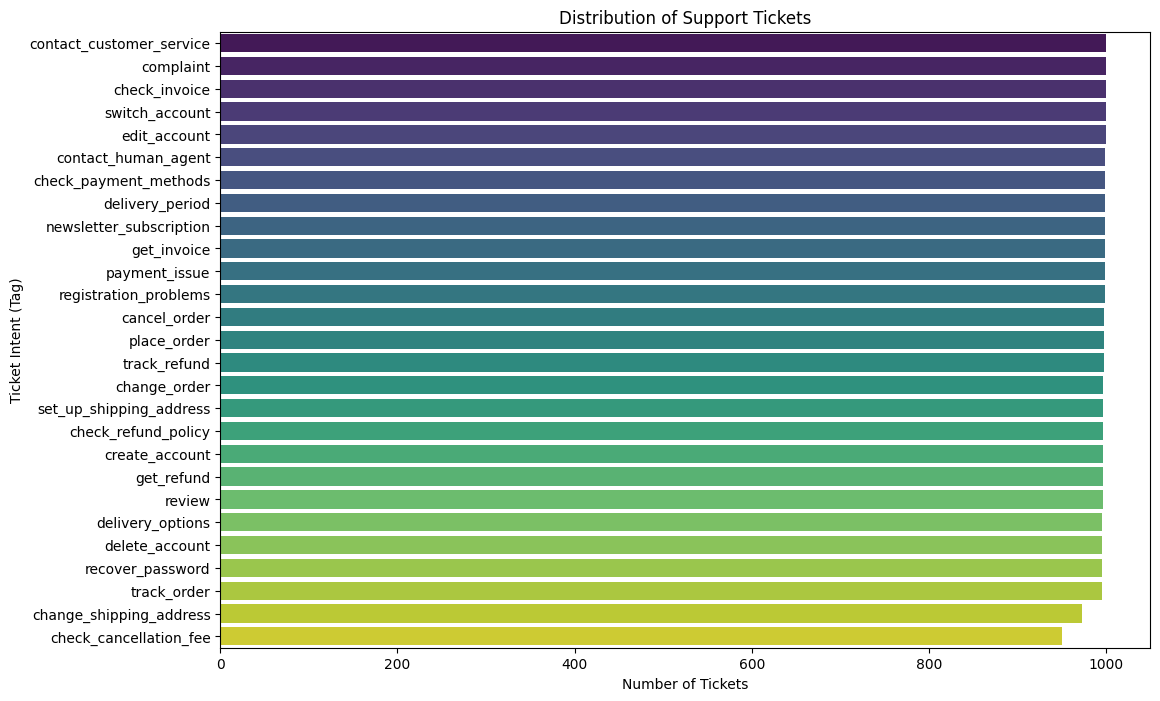

In [ ]:
# Import Plotting Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Count Ticket Categories
category_counts = df['true_label'].value_counts()

# Display Category Counts
print(category_counts)

# Plot Data Distribution
plt.figure(figsize=(12, 8))
sns.barplot(y=category_counts.index, x=category_counts.values, hue=category_counts.index, legend=False, palette="viridis")
plt.title("Distribution of Support Tickets")
plt.xlabel("Number of Tickets")
plt.ylabel("Ticket Intent (Tag)")
plt.show()

In [ ]:
# Find Minimum Count
min_count = df['true_label'].value_counts().min()

# Balance The Dataset
df_balanced = df.groupby('true_label').sample(n=min_count, random_state=42)

# Reset The Index
df = df_balanced.reset_index(drop=True)

# Verify Perfect Balance
print("Dataset is perfectly balanced!")
print(df['true_label'].value_counts())

Dataset is perfectly balanced!
true_label
cancel_order                950
change_order                950
change_shipping_address     950
check_cancellation_fee      950
check_invoice               950
check_payment_methods       950
check_refund_policy         950
complaint                   950
contact_customer_service    950
contact_human_agent         950
create_account              950
delete_account              950
delivery_options            950
delivery_period             950
edit_account                950
get_invoice                 950
get_refund                  950
newsletter_subscription     950
payment_issue               950
place_order                 950
recover_password            950
registration_problems       950
review                      950
set_up_shipping_address     950
switch_account              950
track_order                 950
track_refund                950
Name: count, dtype: int64


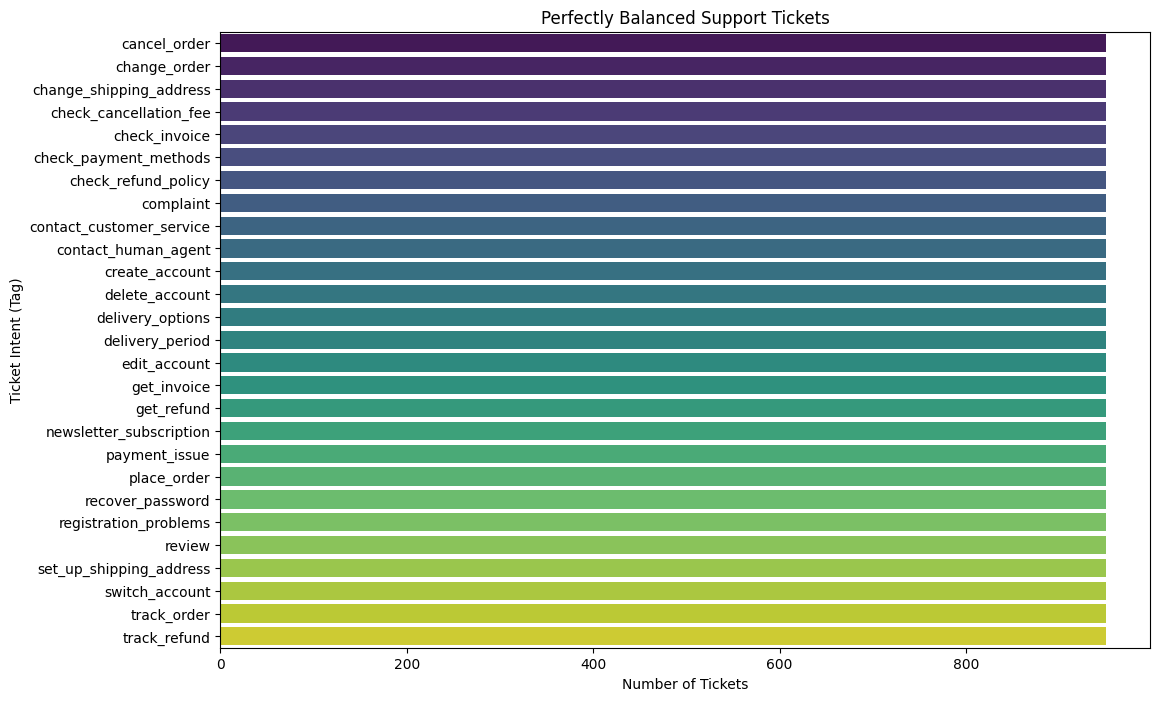

In [ ]:
# Import Plotting Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Count Balanced Categories
balanced_counts = df_balanced['true_label'].value_counts()

# Plot Balanced Data
plt.figure(figsize=(12, 8))
sns.barplot(y=balanced_counts.index, x=balanced_counts.values, hue=balanced_counts.index, legend=False, palette="viridis")
plt.title("Perfectly Balanced Support Tickets")
plt.xlabel("Number of Tickets")
plt.ylabel("Ticket Intent (Tag)")
plt.show()

In [ ]:
from transformers import pipeline
from sklearn.metrics import accuracy_score
import torch

# 1. Verify GPU is actually working
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    print("✅ GPU is ACTIVE! This should be lightning fast.")
else:
    print("⚠️ WARNING: GPU is offline. Running on CPU (this will be slow).")

# 2. Fast-Track Evaluation (10 tickets only)
df_eval_fast = df_balanced.sample(n=10, random_state=42).reset_index(drop=True)
candidate_tags = df_balanced['true_label'].unique().tolist()

zero_shot_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)
zero_shot_results = []

print("⏳ Processing 10 Support Tickets...")
for index, row in df_eval_fast.iterrows():
    result = zero_shot_classifier(row['ticket'], candidate_tags)
    zero_shot_results.append(result['labels'][0])

zero_shot_acc = accuracy_score(df_eval_fast['true_label'], zero_shot_results)
print(f"\n🚀 DONE! Fast-Track Zero-Shot Accuracy: {zero_shot_acc * 100:.2f}%")

✅ GPU is ACTIVE! This should be lightning fast.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

⏳ Processing 10 Support Tickets...

🚀 DONE! Fast-Track Zero-Shot Accuracy: 30.00%


In [ ]:
# Import Required Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import AutoTokenizer

# Encode Text Labels
le = LabelEncoder()
df_balanced['encoded_labels'] = le.fit_transform(df_balanced['true_label'])

# Split Training Data
train_df, val_df = train_test_split(df_balanced, test_size=0.2, random_state=42)

# Convert To Datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# Load DistilBERT Tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_data(example):
    return tokenizer(example["ticket"], padding="max_length", truncation=True, max_length=128)

# Tokenize Ticket Text
train_tokenized = train_dataset.map(tokenize_data, batched=True)
val_tokenized = val_dataset.map(tokenize_data, batched=True)

# Format For PyTorch
train_tokenized = train_tokenized.rename_column("encoded_labels", "labels")
val_tokenized = val_tokenized.rename_column("encoded_labels", "labels")
train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("✅ Data Tokenized Successfully!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/20520 [00:00<?, ? examples/s]

Map:   0%|          | 0/5130 [00:00<?, ? examples/s]

✅ Data Tokenized Successfully!


In [ ]:
# Import Training Libraries
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import accuracy_score
import numpy as np

# Load DistilBERT Model
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_labels)

# Define Accuracy Metric
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# Set Training Arguments
training_args = TrainingArguments(
    output_dir="./ticket_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

# Initialize Model Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Start Model Training
print("🚀 Starting Fine-Tuning...")
trainer.train()
print("✅ Training Complete!")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Starting Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.053997,0.014682,0.997076
2,0.006818,0.009680,0.997661
3,0.001498,0.005527,0.998635
4,0.000512,0.005234,0.998441
5,0.000380,0.004318,0.998635


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Training Complete!


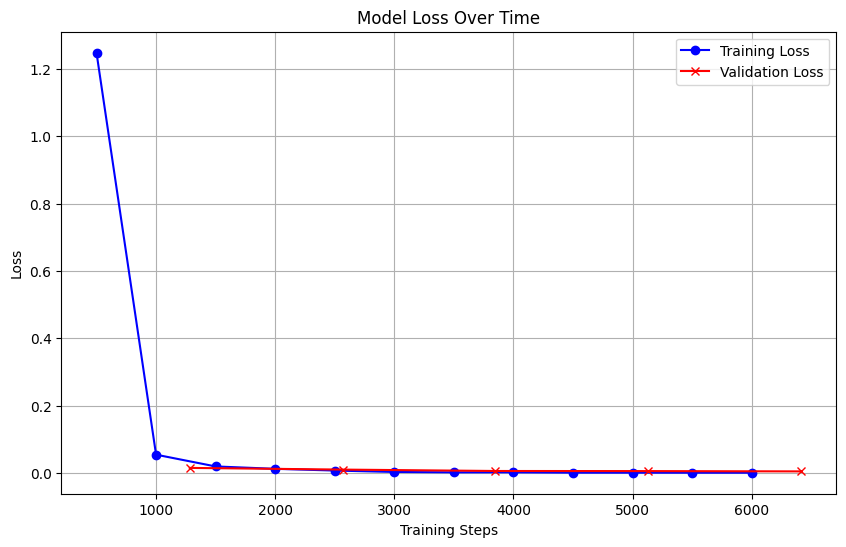

In [ ]:
# Import Plotting Libraries
import matplotlib.pyplot as plt

# Extract Training Logs
log_history = trainer.state.log_history
train_steps = []
train_losses = []
val_steps = []
val_losses = []

for log in log_history:
    if 'loss' in log:
        train_steps.append(log['step'])
        train_losses.append(log['loss'])
    elif 'eval_loss' in log:
        val_steps.append(log['step'])
        val_losses.append(log['eval_loss'])

# Plot Loss Graph
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(val_steps, val_losses, label='Validation Loss', color='red', marker='x')
plt.title("Model Loss Over Time")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Import Evaluation Libraries
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# Switch Model Mode
model.eval()

# Initialize Results Lists
fine_tuned_preds = []
true_labels = []

print("⏳ Evaluating Fine-Tuned Model...")

# Run Validation Loop
with torch.no_grad():
    for batch in val_tokenized:
        # Format Tensor Inputs (Using .unsqueeze(0) to add batch dimension)
        input_ids = batch['input_ids'].unsqueeze(0).to(model.device)
        attention_mask = batch['attention_mask'].unsqueeze(0).to(model.device)

        # Get Model Output
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits[0]

        # Convert To Probabilities
        probs = torch.nn.functional.softmax(logits, dim=0).cpu().numpy()

        # Extract Top Predictions
        top_indices = np.argsort(probs)[::-1][:3]
        top_tags = [le.inverse_transform([idx])[0] for idx in top_indices]
        top_scores = [probs[idx] for idx in top_indices]

        # Save Top Prediction
        fine_tuned_preds.append(top_indices[0])
        true_labels.append(batch['labels'].item()) # .item() safely extracts the integer

        # Print Sample Outputs
        if len(fine_tuned_preds) <= 3:
            ticket_text = tokenizer.decode(batch['input_ids'], skip_special_tokens=True)
            print(f"\nTicket: '{ticket_text}'")
            print("Top Probable Tags:")
            for tag, score in zip(top_tags, top_scores):
                print(f" - {tag}: {score:.2%}")

# Compare Model Accuracy
fine_tuned_acc = accuracy_score(true_labels, fine_tuned_preds)
print(f"\n🎯 Fine-Tuned Accuracy: {fine_tuned_acc * 100:.2f}%")
print(f"📈 Improvement Over Zero-Shot: {(fine_tuned_acc - 0.30) * 100:.2f}%")

⏳ Evaluating Fine-Tuned Model...

Ticket: 'need to get the invoicefrom { { person name } } can i get some help'
Top Probable Tags:
 - get_invoice: 99.98%
 - check_invoice: 0.00%
 - newsletter_subscription: 0.00%

Ticket: 'change to the { { account type } } account'
Top Probable Tags:
 - switch_account: 99.98%
 - edit_account: 0.00%
 - create_account: 0.00%

Ticket: 'i cannot see the current staus of purchase { { order number } }'
Top Probable Tags:
 - track_order: 99.98%
 - change_order: 0.00%
 - cancel_order: 0.00%

🎯 Fine-Tuned Accuracy: 99.86%
📈 Improvement Over Zero-Shot: 69.86%


In [ ]:
# Import LangChain Libraries
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

# Set API Key
os.environ["GOOGLE_API_KEY"] = "API_KEY"

# Load Gemini Model
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.1)

# Create Prompt Template
few_shot_prompt = PromptTemplate.from_template("""
You are an expert customer support routing AI.
Categorize the user's ticket into exactly ONE of these categories: {categories}

Here are examples to learn from:
Ticket: "I never received my tracking number for my purchase."
Tags: track_order, delivery_period, contact_customer_service

Ticket: "I want to cancel the item I just bought."
Tags: cancel_order, get_refund, change_order

Now, process this real ticket and output the top most likely tags in the exact same format:
Ticket: "{ticket}"
Tags:
""")

# Test Gemini AI
print("🤖 Testing Few-Shot Gemini...")
test_ticket_text = df_eval_fast['ticket'].iloc[0]
chain = few_shot_prompt | llm

# Get LLM Response
response = chain.invoke({
    "categories": ", ".join(candidate_tags),
    "ticket": test_ticket_text
})

# Print Final Output
print(f"\nTicket: '{test_ticket_text}'")
print(response.content)

🤖 Testing Few-Shot Gemini...

Ticket: 'need to get the invoicefrom {{Person Name}} can i get some help'
Tags: get_invoice


In [ ]:
# Import Colab Files
from google.colab import files
import os

# Save Trained Model
trainer.save_model("./final_ticket_model")

# Save Model Tokenizer
tokenizer.save_pretrained("./final_ticket_model")

print("✅ Model saved to Colab! Zipping files now...")

# Zip Model Folder
os.system("zip -r final_ticket_model.zip ./final_ticket_model")

print("✅ Zipping complete! Triggering browser download...")

# Download To Computer
files.download("final_ticket_model.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to Colab! Zipping files now...
✅ Zipping complete! Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Import Drive tools
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define File Paths
source_file = "final_ticket_model.zip"
drive_destination = "/content/drive/MyDrive/final_ticket_model.zip"

print("⏳ Copying model to Drive...")

# Copy The File
shutil.copy(source_file, drive_destination)

print("✅ Successfully uploaded to Google Drive!")

Mounted at /content/drive
⏳ Copying model to Drive...
✅ Successfully uploaded to Google Drive!
